<a href="https://colab.research.google.com/github/rahul-7718/MEACHINE-LEARNING/blob/main/2420080025_week_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A: Data Loading and Preparation
Loading Fashion-MNIST dataset...
Dataset shape: (3000, 784)
Number of samples: 3000
Number of features: 784
Number of classes: 10
Class distribution: [300 288 293 296 288 307 311 298 289 330]

Normalizing pixel values...


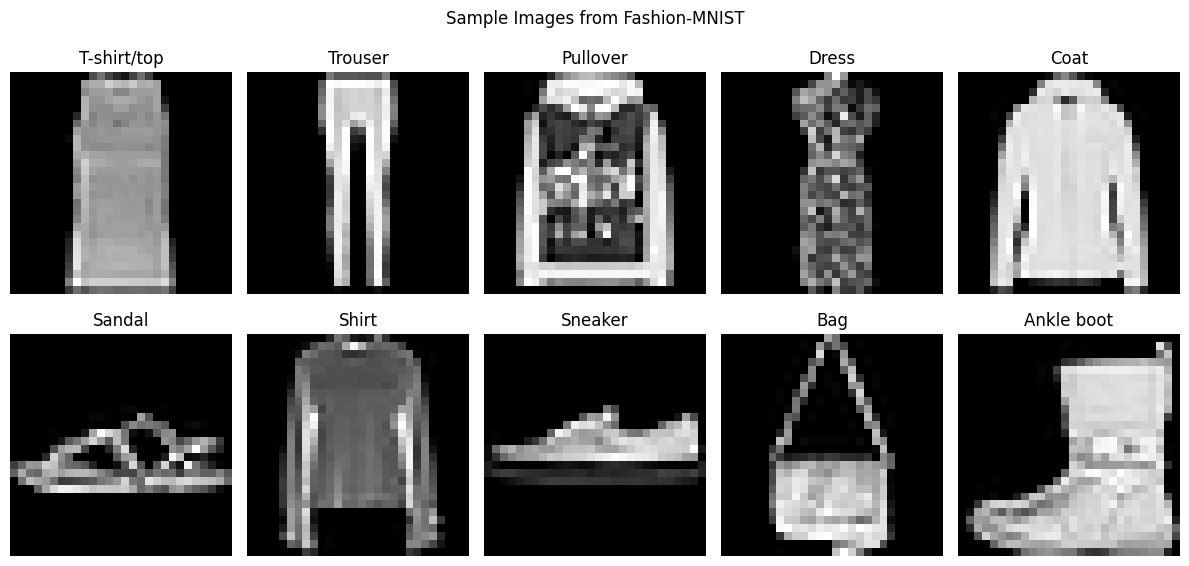


Part B: PCA Implementation
Applying PCA...
PCA time: 0.32 seconds


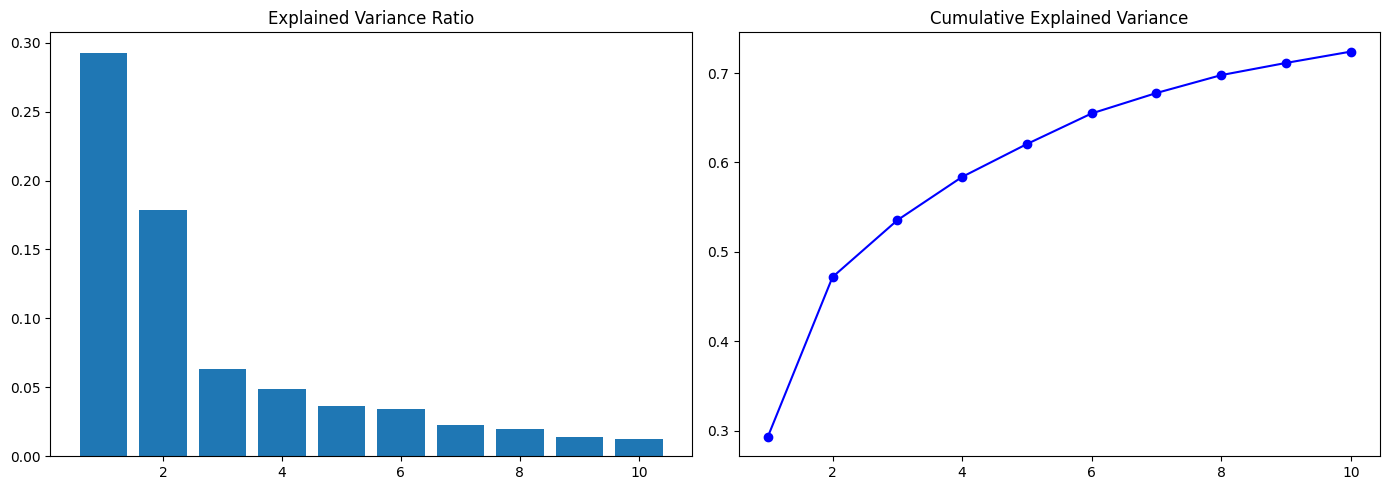

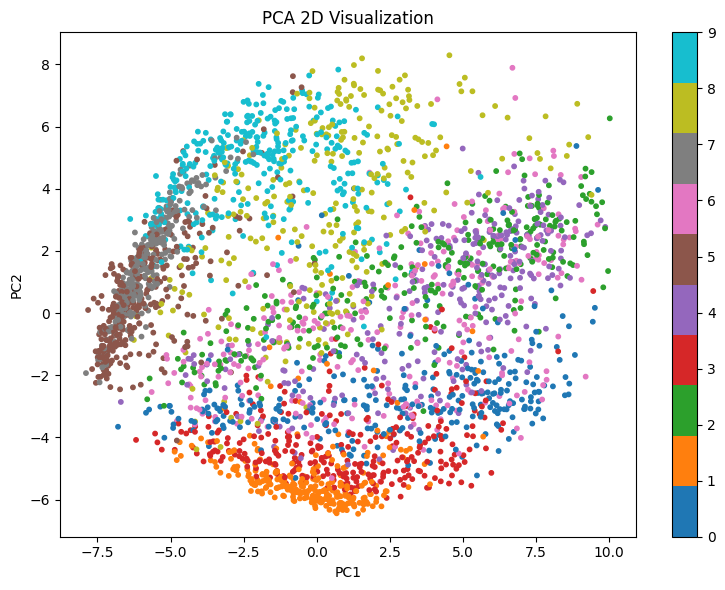


Part C: t-SNE Implementation
Running t-SNE with perplexity=5
Time: 25.93 sec
Running t-SNE with perplexity=30
Time: 28.66 sec
Running t-SNE with perplexity=50
Time: 34.10 sec


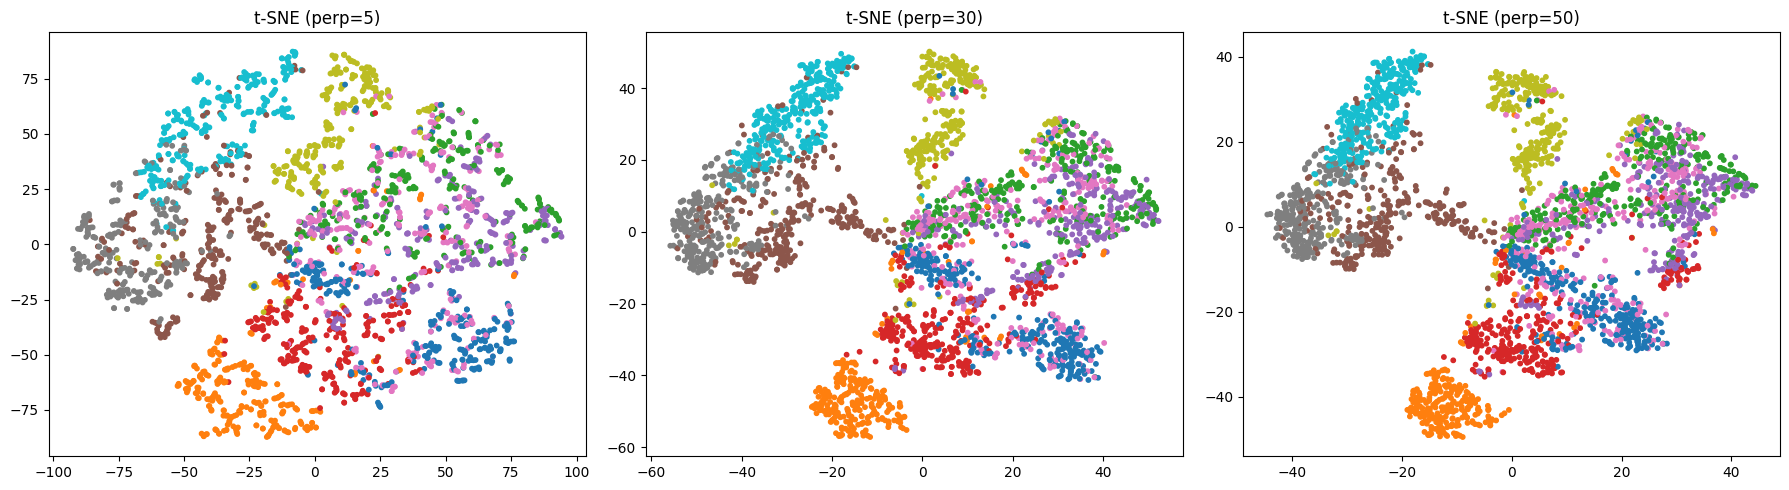


Part D: Comparison and Analysis

--- Computation Time ---
PCA: 0.32 sec
t-SNE (perp=5): 25.93 sec
t-SNE (perp=30): 28.66 sec
t-SNE (perp=50): 34.10 sec


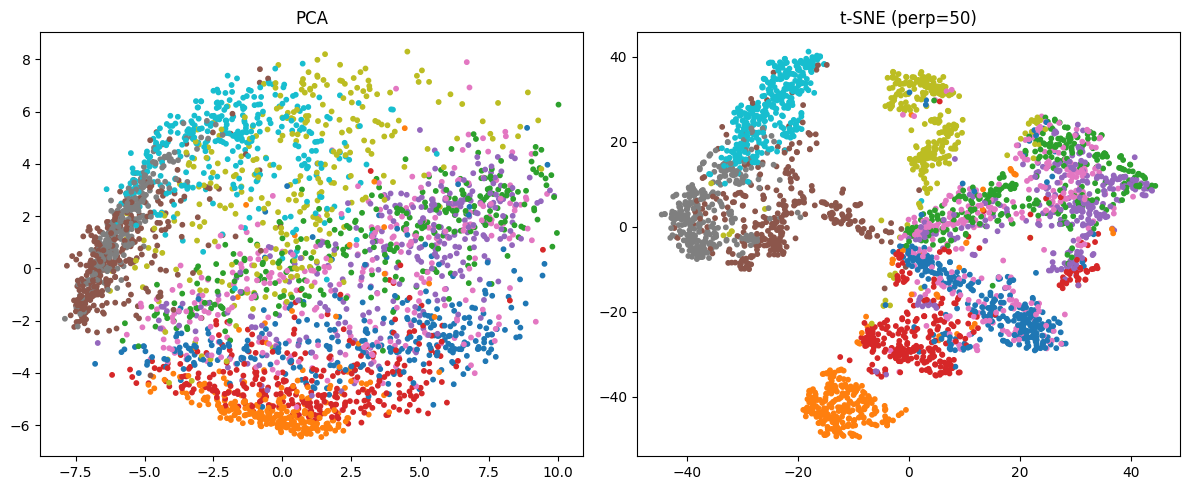


--- Cluster Separation ---
PCA: -0.036
t-SNE (perp=5): 0.123
t-SNE (perp=30): 0.167
t-SNE (perp=50): 0.177


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time
import warnings

warnings.filterwarnings('ignore')

# =========================
# Part A: Data Loading
# =========================
print("=" * 50)
print("Part A: Data Loading and Preparation")
print("=" * 50)

print("Loading Fashion-MNIST dataset...")
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

X = fashion_mnist.data
y = fashion_mnist.target.astype(int)

# Use subset for speed
n_samples = 3000
np.random.seed(42)
indices = np.random.choice(X.shape[0], n_samples, replace=False)
X = X[indices]
y = y[indices]

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

# Class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize
print("\nNormalizing pixel values...")
X_normalized = X / 255.0

# =========================
# Visualize Images
# =========================
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.where(y == i)[0][0]
    axes[i].imshow(X[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(class_names[i])
    axes[i].axis('off')

plt.suptitle("Sample Images from Fashion-MNIST")
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png')
plt.show()

# =========================
# Part B: PCA
# =========================
print("\n" + "=" * 50)
print("Part B: PCA Implementation")
print("=" * 50)

print("Applying PCA...")
start_time = time.time()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

pca_time = time.time() - start_time
print(f"PCA time: {pca_time:.2f} seconds")

# Explained variance
pca_full = PCA(n_components=10)
pca_full.fit(X_normalized)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10])
axes[0].set_title("Explained Variance Ratio")

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 11), cumulative_variance[:10], 'bo-')
axes[1].set_title("Cumulative Explained Variance")

plt.tight_layout()
plt.savefig('pca_variance.png')
plt.show()

# PCA Visualization
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
plt.title("PCA 2D Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter)
plt.tight_layout()
plt.savefig('pca_visualization.png')
plt.show()

# =========================
# Part C: t-SNE
# =========================
print("\n" + "=" * 50)
print("Part C: t-SNE Implementation")
print("=" * 50)

perplexities = [5, 30, 50]
tsne_results = {}
tsne_times = {}

fig, axes = plt.subplots(1, len(perplexities), figsize=(18, 5))

for i, perplexity in enumerate(perplexities):
    print(f"Running t-SNE with perplexity={perplexity}")

    start_time = time.time()

    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=42, max_iter=1000)

    X_tsne = tsne.fit_transform(X_normalized)

    tsne_time = time.time() - start_time

    tsne_results[perplexity] = X_tsne
    tsne_times[perplexity] = tsne_time

    print(f"Time: {tsne_time:.2f} sec")

    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=10)
    axes[i].set_title(f"t-SNE (perp={perplexity})")

plt.tight_layout()
plt.savefig('tsne_comparison.png')
plt.show()

# =========================
# Part D: Comparison
# =========================
print("\n" + "=" * 50)
print("Part D: Comparison and Analysis")
print("=" * 50)

print("\n--- Computation Time ---")
print(f"PCA: {pca_time:.2f} sec")
for p, t in tsne_times.items():
    print(f"t-SNE (perp={p}): {t:.2f} sec")

# PCA vs t-SNE best
best_perplexity = 50

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
axes[0].set_title("PCA")

axes[1].scatter(tsne_results[best_perplexity][:, 0],
                tsne_results[best_perplexity][:, 1],
                c=y, cmap='tab10', s=10)
axes[1].set_title(f"t-SNE (perp={best_perplexity})")

plt.tight_layout()
plt.savefig('pca_vs_tsne.png')
plt.show()

# =========================
# Silhouette Score
# =========================
print("\n--- Cluster Separation ---")

def analyze_clusters(X_embedded, y_true, name):
    try:
        if len(X_embedded) > 10000:
            idx = np.random.choice(len(X_embedded), 10000, replace=False)
            score = silhouette_score(X_embedded[idx], y_true[idx])
        else:
            score = silhouette_score(X_embedded, y_true)

        print(f"{name}: {score:.3f}")
    except Exception as e:
        print(f"{name} failed: {e}")

analyze_clusters(X_pca, y, "PCA")

for p in perplexities:
    analyze_clusters(tsne_results[p], y, f"t-SNE (perp={p})")
